## <font color = '#6495ED'>  ______________________ **Text Mining - Stock Sentiment** _____________________
#### _______________________________________________Academic Year: 2024/2025 _____________________________________________

<div style="text-align: center;">
    <strong>Group 31</strong>
    <table style="margin: 0 auto; border-collapse: collapse; border: 1px solid black;">
        <tr>
            <th style="border: 1px solid white; padding: 8px;">Name</th>
            <th style="border: 1px solid white; padding: 8px;">Student ID</th>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">David Cascão</td>
            <td style="border: 1px solid white; padding: 8px;">20240851</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Elcano Gaspar</td>
            <td style="border: 1px solid white; padding: 8px;">20241021</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Jorge Cordeiro</td>
            <td style="border: 1px solid white; padding: 8px;">20240594</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Rui Reis</td>
            <td style="border: 1px solid white; padding: 8px;">20240854</td>
        </tr>
    </table>
</div>

### <font color = '#6495ED'>  **1. Libraries, Functions, Configuration and Datasets** </font>

#### <font color = '#6495ED'> **1.1. Import the Needed Libraries** </font>

In [1]:
#Data management
import numpy as np
import pandas as pd
import csv

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import pointbiserialr

from collections import Counter


from sklearn.metrics import classification_report

#Preprocessing
import string
from tqdm import tqdm
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

#Visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from textblob import TextBlob
import plotly.express as px

import time
from tqdm import tqdm

#### <font color = '#6495ED'> **1.2. Setup and Configuration** </font>

In [2]:
# Download required NLTK resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
pd.set_option('display.max_colwidth', None)
# Set seaborn style and matplotlib defaults
sns.set(style="whitegrid", color_codes= "#152645", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.dpi'] = 100

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


#### <font color = '#6495ED'>**1.3. Load the Dataset** </font>

In [3]:
train = pd.read_csv("/content/train.csv")


### <font color = '#6495ED'> **3. Preprocessing** </font>

#### <font color = '#6495ED'> **3.1. Corpus split** </font>

In [4]:
val, train = train_test_split(train, test_size=0.2,random_state=42,stratify=train["label"])

#### <font color = '#6495ED'> **3.2. Data Cleaning for Generative Models** </font>

In [5]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 10.1 MB/s eta 0:00:00


In [6]:
import re
import emoji
from tqdm import tqdm

def clean_for_generative_models(text_list):

    cleaned = []

    for text in tqdm(text_list, desc="Cleaning texts"):
        # Remove URLs
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)
        # Remove mentions
        text = re.sub(r"@\w+", "", text)
        # Remove hashtags (keep the word)
        text = re.sub(r"#(\w+)", r"\1", text)
        # Remove emojis
        text = emoji.replace_emoji(text, replace='')
        # Remove extra whitespace and unwanted symbols
        text = re.sub(r"[“”‘’•…]", "", text)
        text = re.sub(r"[^\w\s.,!?$%-]", "", text)
        text = re.sub(r"\s+", " ", text).strip()
        cleaned.append(text)

    return cleaned

train["clean_text"] = clean_for_generative_models(train["text"].tolist())

Cleaning texts: 100%|██████████| 1909/1909 [00:00<00:00, 15007.99it/s]


In [7]:
train.sample(5,random_state=25)

,text,label,clean_text
7810,$AUPH - Aurinia's Successful Study In Lupus Nephritis Changes The Scope Of Treatment Options For Patients. Follow t… https://t.co/DbMxN5iCwi,1,$AUPH - Aurinias Successful Study In Lupus Nephritis Changes The Scope Of Treatment Options For Patients. Follow t
8393,Are Kapsch TrafficCom AG’s Returns On Capital Worth Investigating?,2,Are Kapsch TrafficCom AGs Returns On Capital Worth Investigating?
5325,Thriving in a trade war: Japan's Murata finds a way https://t.co/Bw89pdztqe,2,Thriving in a trade war Japans Murata finds a way
1071,$ALXN said that it will maintain an active dialogue with shareholders and welcomes constructive impact” https://t.co/nPMG69yiLb,2,$ALXN said that it will maintain an active dialogue with shareholders and welcomes constructive impact
7676,$ING - ING May Be Through The Worst Point Of The Cycle. Read more: https://t.co/wTGUTspx6E #stockmarket #economy #investing,0,$ING - ING May Be Through The Worst Point Of The Cycle. Read more stockmarket economy investing


#### <font color = '#6495ED'> **3.3. Generative Models for Classification** </font>

In [8]:
!pip install -q transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.8 MB/s eta 0:00:00


In [9]:
# Import main libraries
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# Define model name and cache directory
model_name = "openchat/openchat-3.5-0106"
cache_dir = "/content/model_cache"

# Load tokenizer and model to GPU using accelerate
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    cache_dir=cache_dir,
    torch_dtype=torch.float16,
    device_map="auto"  # Automatically selects GPU if available
)

# Create the text generation pipeline (no 'device' argument!)
text_generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

print("✅ Model loaded successfully and running on GPU (if available)")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/179 [00:00<?, ?B/s]

✅ Model loaded successfully and running on GPU (if available)


In [10]:
from sklearn.metrics import classification_report
def evaluate_performance(y_true, y_pred):
    print(classification_report(y_true, y_pred, target_names=["Bearish", "Bullish", "Neutral"]))

In [11]:
def zero_shot_prompt(text):
    return f"""You are a financial sentiment classifier.

Classify the sentiment of the following financial news text into one of the following categories:
- 0 = Bearish (negative sentiment)
- 1 = Bullish (positive sentiment)
- 2 = Neutral (neutral sentiment)

Text: "{text}" , Only respond with a single number: 0, 1, or 2."""

In [12]:
def classify_with_model(prompt):
    response = text_generator(
        prompt,
        max_new_tokens=10,
        do_sample=False
    )[0]["generated_text"]
    matches = re.findall(r"\b[012]\b", response)
    return int(matches[-1])

In [13]:
expirement=train.sample(5)
expirement

,text,label,clean_text
5344,Top 5 Things to Know in the Market on Thursday,2,Top 5 Things to Know in the Market on Thursday
6204,"The New York Fed's March survey of consumer expectations showed ""a substantial deterioration in financial and econo… https://t.co/jKdqGTgCm9",0,The New York Feds March survey of consumer expectations showed a substantial deterioration in financial and econo
850,Qualcomm Projects Uneven Sales Growth on Pickup of 5G,0,Qualcomm Projects Uneven Sales Growth on Pickup of 5G
147,"$MU $WDC - Bull sees 2020 upsides for MU, WDC https://t.co/65zGfs82xI",1,"$MU $WDC - Bull sees 2020 upsides for MU, WDC"
6189,China's house price growth to hit five-year low in 2020 - Reuters poll #economy #MarketScreener… https://t.co/YeX2IUjYw1,0,Chinas house price growth to hit five-year low in 2020 - Reuters poll economy MarketScreener


In [14]:
for text in expirement["clean_text"]:
    prompt = zero_shot_prompt(text)
    prediction = classify_with_model(prompt)
    print(f"Text: {text}, Prediction: {prediction}\n")

Text: Top 5 Things to Know in the Market on Thursday, Prediction: 2

Text: The New York Feds March survey of consumer expectations showed a substantial deterioration in financial and econo, Prediction: 0

Text: Qualcomm Projects Uneven Sales Growth on Pickup of 5G, Prediction: 2

Text: $MU $WDC - Bull sees 2020 upsides for MU, WDC, Prediction: 1

Text: Chinas house price growth to hit five-year low in 2020 - Reuters poll economy MarketScreener, Prediction: 0



In [15]:
from tqdm import tqdm

train_preds_zero = []
for text in tqdm(train["clean_text"], desc="Classifying training data"):
    prompt = zero_shot_prompt(text)
    prediction = classify_with_model(prompt)
    train_preds_zero.append(prediction)


Classifying training data: 100%|██████████| 1909/1909 [1:46:55<00:00,  3.36s/it]


In [16]:
evaluate_performance(train["label"].tolist(), train_preds_zero)

              precision    recall  f1-score   support

     Bearish       0.55      0.91      0.69       288
     Bullish       0.67      0.90      0.77       385
     Neutral       0.95      0.70      0.80      1236

    accuracy                           0.77      1909
   macro avg       0.72      0.84      0.75      1909
weighted avg       0.83      0.77      0.78      1909



##### <font color = '#6495ED'> **3.3.1. Few-Shot Classification** </font>

In [17]:
few_shot_examples = [
    ("Deutsche Bank sues over $1.6 billion in claims against Bernard Madoff’s bankrupt investment advisory business", 0),
    ("Hedge Funds Are Dumping Ocwen Financial Corporation (OCN)",0),
    ("$BLRX - BioLineRx up big ahead of key data readout ",1),
    ("Axcelis Technologies stock price target raised to $32 from $24 at Benchmark", 1),
    ("Web inventor has an ambitious plan to take back the net", 2),
    ("Iran joins Russia and China in joint naval exercises beginning Friday",2)
]

def few_shot_prompt(text, examples=few_shot_examples):
    prompt = """You are a financial sentiment classifier.

Here are the definitions for each category:
- **Bearish (0):** Indicates a negative outlook or expectation of decline for a stock, company, or the overall market. Look for keywords related to price drops, downgrades, losses, selling, or negative news.
- **Bullish (1):** Indicates a positive outlook or expectation of rise for a stock, company, or the overall market. Look for keywords related to gains, upgrades, strong performance, buying, or positive news.
- **Neutral (2):** Indicates a lack of strong positive or negative sentiment, or expresses factual information without a clear market bias. This includes general news that doesn't imply a clear direction for the stock or market.

Here are some examples:
"""
    for ex_text, ex_label in examples:
        prompt += f'Text: "{ex_text}"\nAnswer: {ex_label}\n\n'

    prompt += f'Text: "{text}"\nAnswer:'
    return prompt


In [18]:
for text in expirement["clean_text"]:
    prompt = few_shot_prompt(text)
    prediction = classify_with_model(prompt)
    print(f"Text: {text}, Prediction: {prediction}\n")

Text: Top 5 Things to Know in the Market on Thursday, Prediction: 2

Text: The New York Feds March survey of consumer expectations showed a substantial deterioration in financial and econo, Prediction: 0

Text: Qualcomm Projects Uneven Sales Growth on Pickup of 5G, Prediction: 1

Text: $MU $WDC - Bull sees 2020 upsides for MU, WDC, Prediction: 1

Text: Chinas house price growth to hit five-year low in 2020 - Reuters poll economy MarketScreener, Prediction: 0



In [19]:
from tqdm import tqdm

train_preds_few = []
for text in tqdm(train["clean_text"], desc="Classifying training data"):
    prompt = few_shot_prompt(text)
    prediction = classify_with_model(prompt)
    train_preds_few.append(prediction)


Classifying training data: 100%|██████████| 1909/1909 [1:54:26<00:00,  3.60s/it]


In [20]:
evaluate_performance(train["label"].tolist(), train_preds_few)

              precision    recall  f1-score   support

     Bearish       0.61      0.88      0.72       288
     Bullish       0.65      0.87      0.75       385
     Neutral       0.93      0.73      0.82      1236

    accuracy                           0.78      1909
   macro avg       0.73      0.83      0.76      1909
weighted avg       0.82      0.78      0.79      1909



In [21]:
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(y_true, y_pred, labels=["Bearish", "Bullish", "Neutral"], title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels, linewidths=0.5, cbar=False)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

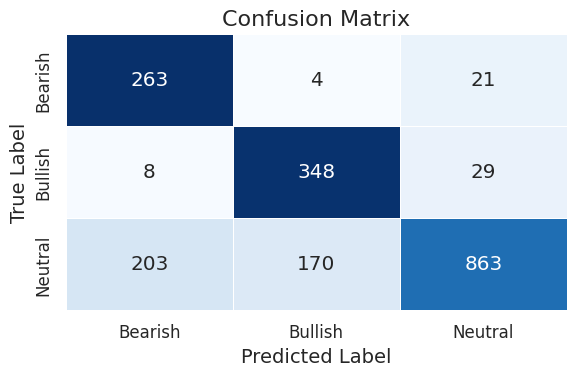

In [22]:
plot_confusion_matrix(train["label"].tolist(),train_preds_zero)

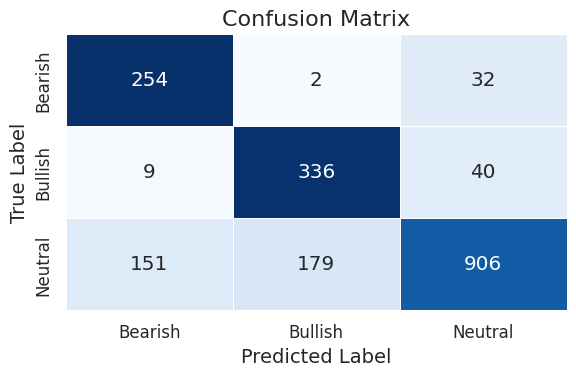

In [23]:
plot_confusion_matrix(train["label"].tolist(),train_preds_few)